**Analyzing Google Play Store Data**    

Internship - Oasis Infobyte (OIBSIP)    
Project 4, Proposal Level 2  
Author - Aniket Mishra

**Overview -**

This project analyzes the Google Play Store apps dataset to understand app characteristics, popularity, user ratings, installs, pricing, and user reviews. The project also performs sentiment analysis on user reviews to identify whether user opinions are positive, neutral, or negative. Various data cleaning, visualization, and exploratory data analysis (EDA) techniques are used to uncover meaningful insights from the dataset.

**Understanding the dataset -**  

The Google Play Store dataset contains information about different apps, their ratings, reviews, etc. It also includes a separate user reviews dataset.      
By analyzing these datasets, we can understand app popularity, download trends, review patterns and overall user sentiment, helping identify the factors that contribute to an app's success on the Google Play Store.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv("D:/Downloads/apps.csv.zip")
data = pd.read_csv("D:/Downloads/user_reviews.csv.zip")

In [3]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB


**Observation -**

We can see several columns having less non null count as compared to range index. Also some columns have wrong data type like `Last Updated` column that needs to be changed.

In [5]:
# Checking Missing Values

df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

**Observation -**

Missing values were found in columns. They needs to be removed.

In [6]:
# Dropping Missing Values

df = df.dropna(subset = ["Current Ver", "Android Ver"])

**Observation -**

Missing records of columns `Current Ver` and `Android Ver` were dropped as they were fewer in number and wouldn't impact the analysis.  
Where as, columns such as `Rating` as well as `Size` were already in `numeric format(float64)`. The missing values were left unchanged in them as they more in number, `1463` and `1227` (NaN) respectively and removing them could significantly affect the data.  
Therefore, they are left unchanged as they do not affect exploratory data analysis and most analysis.

In [7]:
# Checking Duplicate Values

df.duplicated().sum()

np.int64(0)

**Observation -**

No duplicate records were found.

In [8]:
# Removing Unnamed Column

df.drop("Unnamed: 0", axis = 1, inplace = True)

**Observation -**

`Unnamed` column looks like an extra index column that gets saved by mistake. Therefore, it's removed.

In [9]:
# Converting Installs Column

df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "", regex = False)
df["Installs"] = df["Installs"].astype(int)

**Observation -**

The `Installs` column contained `commas(,)` and `plus signs(+)` which prevented it from being treated as numeric data. These symbols were removed and the column was converted to integer format to make it suitable for numerical analysis and visualization.

In [10]:
# Converting Price Column

df["Price"] = df["Price"].str.replace("$", "", regex = False)
df["Price"] = df["Price"].astype(float)

**Observation -**

`Price` column contained `dollar signs($)` along with numeric values. The dollar sign was removed using the `str.replace()` function and the column was converted to a numeric data type using `pd.to_numeric()`.  
This allows the column to be used for calculations, analysis and visualizations.

In [11]:
# Converting Last Updated Column

df["Last Updated"] = pd.to_datetime(df["Last Updated"])

**Observation -**

`Last Updated` column was converted from `text(object)` to `datetime` format. This allows the dates to be analyzed more effectively.

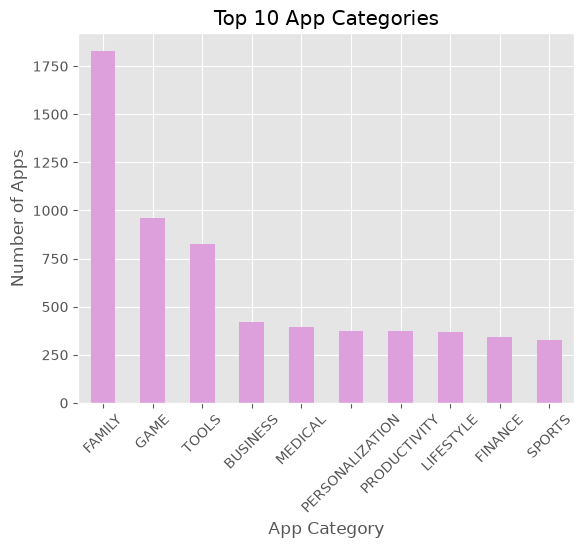

In [37]:
categories = df["Category"].value_counts().head(10)
categories.plot(kind = "bar", color = "plum")
plt.title("Top 10 App Categories")

plt.xlabel("App Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation = 45)
plt.show()

**Observation -**

This graph shows top 10 app categories in the dataset.`X-axis`represents the different`App Categories`, whereas,`Y-axis` represents the `Number of Apps` in each category.  
The `Family` category has the highest number of apps, followed by `Game` and `Tools`.   
The remaining categories contain fewer apps, showing that the distribution of apps is concentrated in only a few categories.

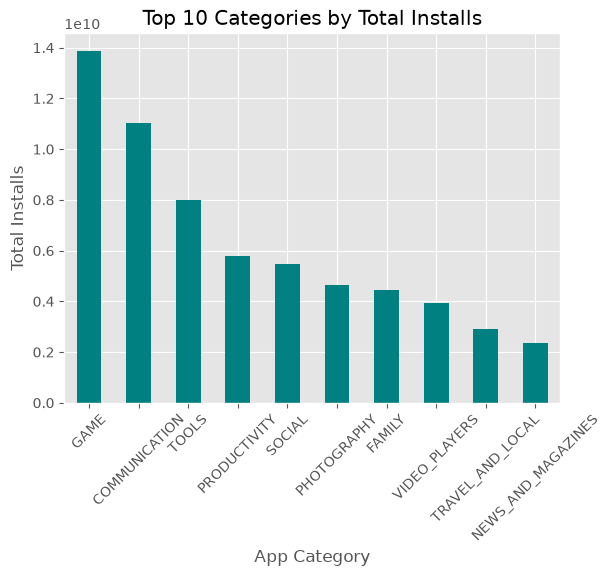

In [56]:
category_installs = df.groupby("Category")["Installs"].sum().sort_values(ascending = False).head(10)
category_installs.plot(kind = "bar", color = "teal")
plt.title("Top 10 Categories by Total Installs")

plt.xlabel("App Category")
plt.ylabel("Total Installs")
plt.xticks(rotation = 45)
plt.show()

**Observation -**

The graph shows the top 10 app categories on the basis of total number of installs. The `X-axis` represents the different `app categories`, whereas`y-axis` represents the `total number of installs` for each category. 
`Game` category has the highest number of installs, followed by `Communication` and `Tools`. This shows that these categories are the most popular among users.  
This also indicates that the categories with more apps (like,`Family`) do not always have the highest number of downloads.

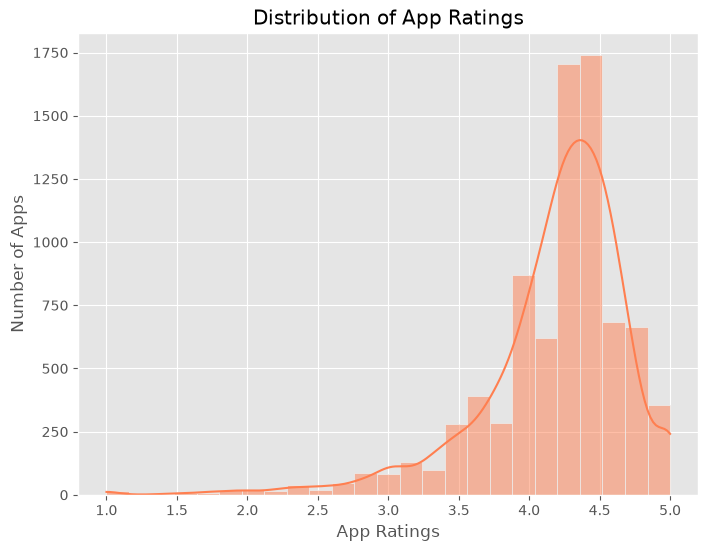

In [52]:
plt.figure(figsize = (8,6))
sns.histplot(df["Rating"], bins = 25, kde = True, color = "coral")

plt.title("Distribution of App Ratings")
plt.xlabel("App Ratings")
plt.ylabel("Number of Apps")
plt.show()

**Observation -**

The graph shows the distributed of app ratings in the dataset.`X-axis`represents the `App Ratings`, whereas,`Y-axis`represents the `Number of Apps`in each rating range.  
Most apps have ratings between `4.0` and `4.5`, whereas, very few apps have ratings below `3.0`.  
This shows that a large number of apps receive positive feedback from users, while, low rated apps are uncommon.

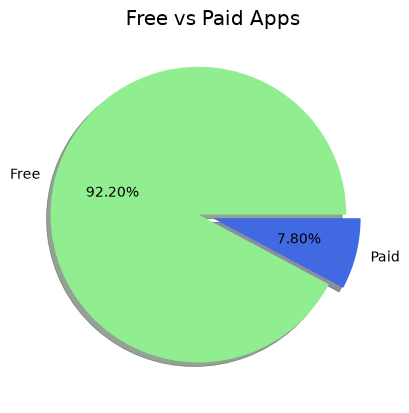

In [46]:
color =("lightgreen","royalblue")
exp = (0.1,0)
df["Type"].value_counts().plot(kind = "pie", autopct = "%1.2f%%", shadow = True, colors = color, explode = exp)

plt.title("Free vs Paid Apps")
plt.show()

**Observation -**

The pie chart shows the distribution of free and paid apps in the dataset. Each slice represents the percentage of apps belonging to a particular type.
The graph shows that `92.2%` of the apps are `free`, while only `7.8%` are paid.  
This shows that free apps dominate the Play Store, making them more widely available to users.

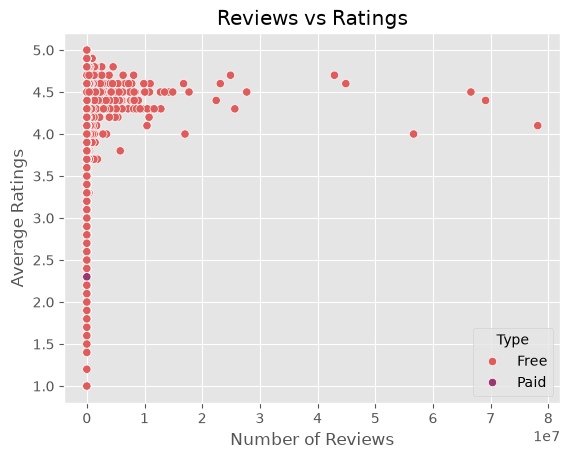

In [51]:
sns.scatterplot(x = "Reviews", y = "Rating", data = df, hue = "Type", palette = "flare")
plt.title("Reviews vs Ratings")

plt.xlabel("Number of Reviews")
plt.ylabel("Average Ratings")
plt.show()

**Observation -**

The graph shows the relationship between the number of reviews and app ratings.`X-axis` represents the `Number of Reviews`received by each app, whereas,`Y-axis` represents the `Average Rating` of each app.  
Most apps have small number of reviews and ratings between `4.0` and `4.5`. A few apps have millions of reviews while having high ratings.  
Overall, there is no relationship between the number of reviews and the app ratings.

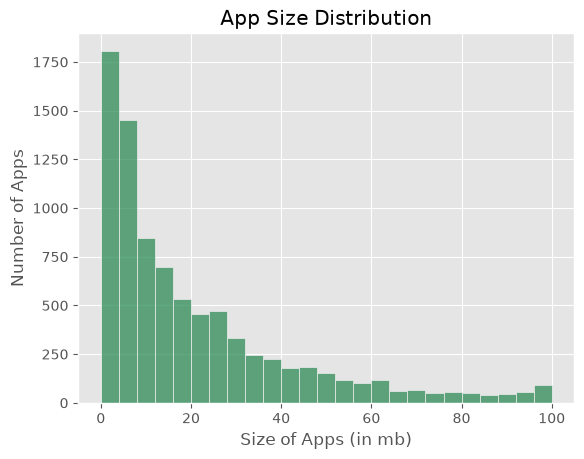

In [60]:
sns.histplot(df["Size"], bins = 25, color = "seagreen")
plt.title("App Size Distribution")

plt.xlabel("Size of Apps (in mb)")
plt.ylabel("Number of Apps")
plt.show()

**Observation -**

The graph shows the distribution of app sizes in the dataset.`X-axis`represents the `Size of Apps`, whereas, `Y-axis` represents the `Number of Apps`in each size range.  
The graph shows that most apps are small in size, with a large number of apps below `20 mb`, while, only a few apps have very large size above `60 mb`.  
This shows that as the app size increases, the number of apps decreases. 

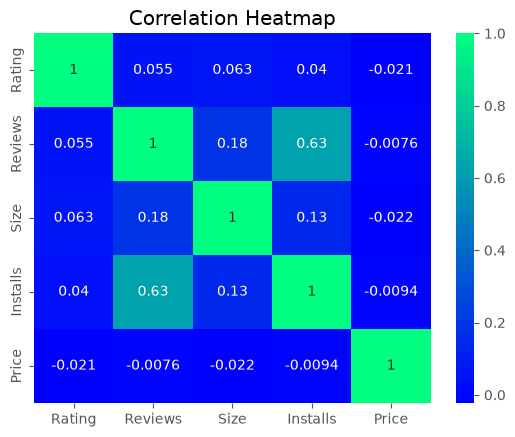

In [55]:
sns.heatmap(df[["Rating", "Reviews", "Size", "Installs", "Price"]].corr(), annot = True, cmap = "winter")
plt.title("Correlation Heatmap")
plt.show()

**Observation -**

The heatmap shows the correlation between the numerical features in the dataset.  
`Reviews` and `Installs` have the strongest positive correlation`0.63`, showing that apps with more reviews generally have more installs.  
Other variables have weak or almost no correlation with each other.  
Price has almost no correlation with any other variable as all its values are close to 0.

In [19]:
data.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [21]:
# Checking Missing Values

data.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

**Observation -**

Missing values were found in the `Review` dataset.

In [22]:
# Removing Missing Values

data = data.dropna()

**Observation -**

All missing values were removed, since these rows did not contain review text or sentiment information, they couldn't be used for sentiment analysis.

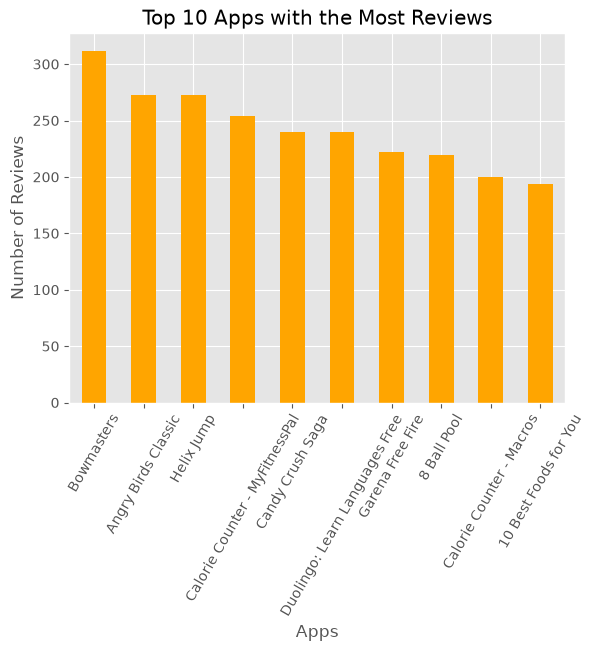

In [57]:
top_apps = data["App"].value_counts().head(10)
top_apps.plot(kind = "bar", color = "orange")
plt.title("Top 10 Apps with the Most Reviews")

plt.xlabel("Apps")
plt.ylabel("Number of Reviews")
plt.xticks(rotation = 60)
plt.show()

**Observation -**

The graph shows the top 10 apps with the highest number of user reviews in the dataset. `X-axis` shows the `Names of Apps`, whereas, `Y-axis` shows the `Total Number of User Reviews`.  
The graph shows that `Bowmasters` has the highest number of reviews, followed by `Angry Birds Classic` and `Helix Jump`.  
This shows that gaming apps dominate in this category as they are in that majority in top 10.

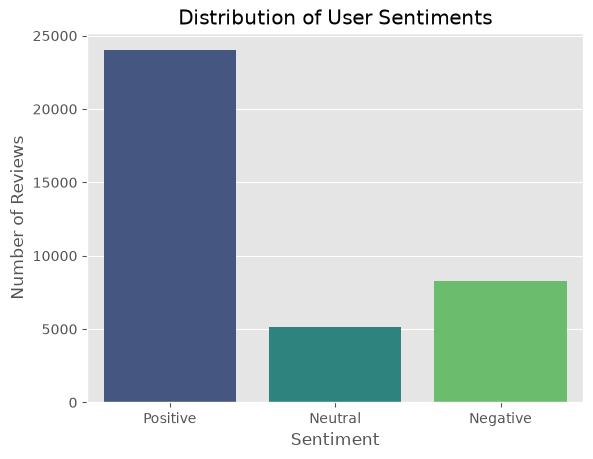

In [59]:
sns.countplot(x = "Sentiment", data = data , hue = "Sentiment", palette = "viridis", legend = False)
plt.title("Distribution of User Sentiments")

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

**Observation -**

The graph shows the distribution of user sentiments in the Google Play Store reviews dataset. `X-axis` represents the `Sentiment Categories` that is, Positive, Neutral and Negative, whereas, `Y-axis` represents the `Number of Reviews` for each sentiment.
`Positive` reviews are the most common, followed by **Negative** reviews, while **Neutral** reviews are the least common. This indicates that most users have a positive opinion about the apps available on the Google Play Store.

In [25]:
data["Sentiment_Polarity"].mean()

np.float64(0.18217064737425184)

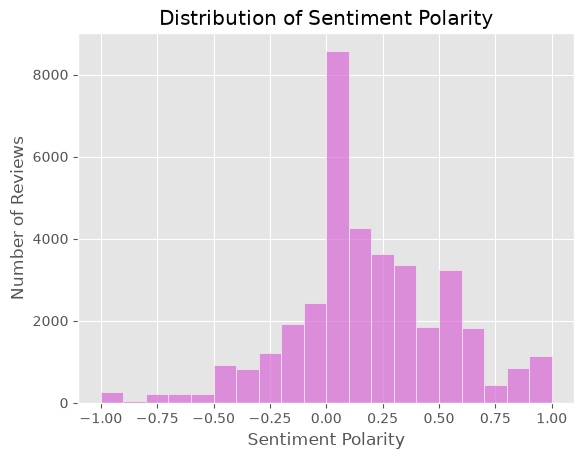

In [63]:
sns.histplot(data["Sentiment_Polarity"], bins = 20, color = "orchid")
plt.title("Distribution of Sentiment Polarity")

plt.xlabel("Sentiment Polarity")
plt.ylabel("Number of Reviews")
plt.show()

**Observation -**

The graph shows the distribution of sentiment polarity scores for user reviews. `X-axis` represents `Sentiment Polarity` in which sentiment score ranges from -1 to +1, whereas, `Y-axis` represents `Number of Reviews` that fall in each sentiment range.  
Most reviews are concentrated between 0 and 0.5, showcasing that majority of users express neutral to positive opinions. Negative reviews are relatively rare, while strongly positive reviews are also present.  
This shows that user feedback is mostly positive, suggesting that the apps in the dataset majorily are well received by users.

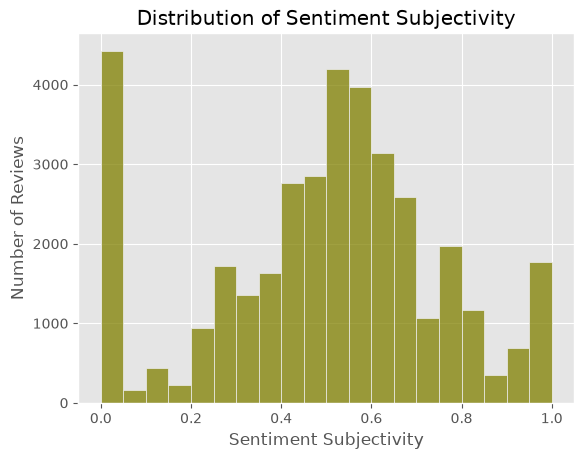

In [65]:
sns.histplot(data["Sentiment_Subjectivity"], bins = 20, color = "olive")
plt.title("Distribution of Sentiment Subjectivity")

plt.xlabel("Sentiment Subjectivity")
plt.ylabel("Number of Reviews")
plt.show()

**Observation -**

The graph shows the distribution of Sentiment Subjectivity in user reviews.    
`X-axis` represents `Sentiment Subjectivity` in which subjectivity ranges from 0 to 1, where 0 is completely objective that is fact based reviews and 1 is completely subjective that is opinion based reviews, whereas, `Y-axis` represents `Number of Reviews` that fall within each subjective range.    
Most reviews fall between `0.4 and 0.6`, showing that users generally express a combination of factual information and personal opinions.   
There are some reviews are purely factual and some that are highly opinion based reviews. Though they are uncommon.

**Key Insights -**  

1. The Family category contains the highest number of apps on the Google Play Store.   
2. Game and Communication apps have the highest total number of installs, showcasing strong user demand.  
3. Developers often choose a free app, possibly generating revenue through advertisements or in app purchases instead of charging an upfront price.  
4. The majority of app ratings are between 4.0 and 4.5.  
5. Most apps are small in size, making them easier to download and install.  
6. User sentiment is mostly positive, with positive reviews significantly outnumbering neutral and negative reviews.  
7. Most reviews have moderate subjectivity, meaning users generally combine facts with personal opinions in their feedback.

**Recommendations -**
  
1. Developers should focus on building free, high quality apps, as they dominate the market and attract more users.   
2. App creators should encourage users to leave reviews.    
3. Maintaining high ratings through regular updates and bug fixes can improve the trust of user.   
4. Minimising app size can help attract more downloads, especially for users with limited storaget.  

**Conclusion -**  

1. The analysis provides valuable insights into the Google Play Store dataset. Most apps are free, receive positive ratings and generate positive user sentiment.
2. Categories such as Family and Games dominate the platform in terms of app availability and installs.
3. The findings also suggest that app quality and regular maintenance are important factors for achieving higher popularity and better user satisfaction.
4. Overall, the dataset shows that positive user experience plays a significant role in an app's success.